## Pre-procesamiento de datos

In [1]:
import numpy as np
import pandas as pd
from scipy.io import arff
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MultipleLocator


In [5]:
data = arff.loadarff('../data/phishing-dataset.arff')
df = pd.DataFrame(data[0])

In [3]:
df = df.map(lambda x: int(x.decode('utf-8')) if isinstance(x, bytes) else x)

In [4]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11055 entries, 0 to 11054
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   having_IP_Address            11055 non-null  int64
 1   URL_Length                   11055 non-null  int64
 2   Shortining_Service           11055 non-null  int64
 3   having_At_Symbol             11055 non-null  int64
 4   double_slash_redirecting     11055 non-null  int64
 5   Prefix_Suffix                11055 non-null  int64
 6   having_Sub_Domain            11055 non-null  int64
 7   SSLfinal_State               11055 non-null  int64
 8   Domain_registeration_length  11055 non-null  int64
 9   Favicon                      11055 non-null  int64
 10  port                         11055 non-null  int64
 11  HTTPS_token                  11055 non-null  int64
 12  Request_URL                  11055 non-null  int64
 13  URL_of_Anchor                11055 non-null  i

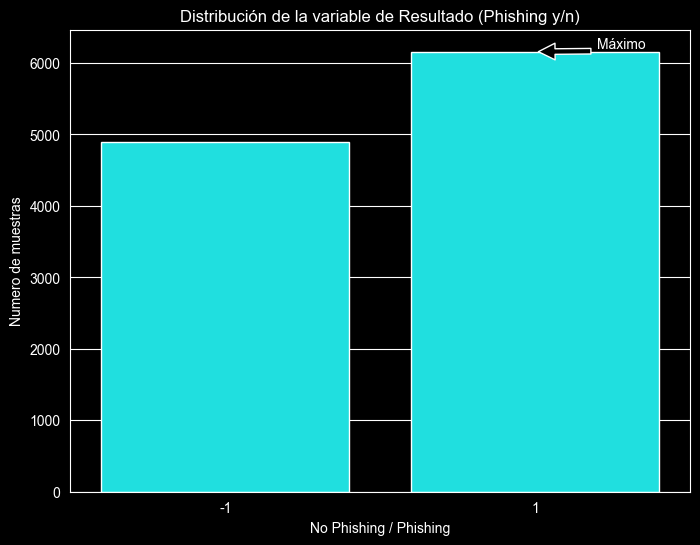

In [36]:
plt.figure(figsize=(8, 6), facecolor='black')
ax = plt.gca()

sns.countplot(x='Result', data=df, color='aqua', ax=ax)

plt.title('Distribución de la variable de Resultado (Phishing y/n)', color='white')
plt.ylabel('Numero de muestras', color='white')
plt.xlabel('No Phishing / Phishing', color='white')

sns.set_style('darkgrid')

ax.set_facecolor('black')
ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')
plt.annotate('Máximo', xy=(1, df['Result'].value_counts()[1]), xytext=(1.2, df['Result'].value_counts()[1]+50),
               arrowprops=dict(facecolor='black', shrink=0.05), color='white')

plt.show()


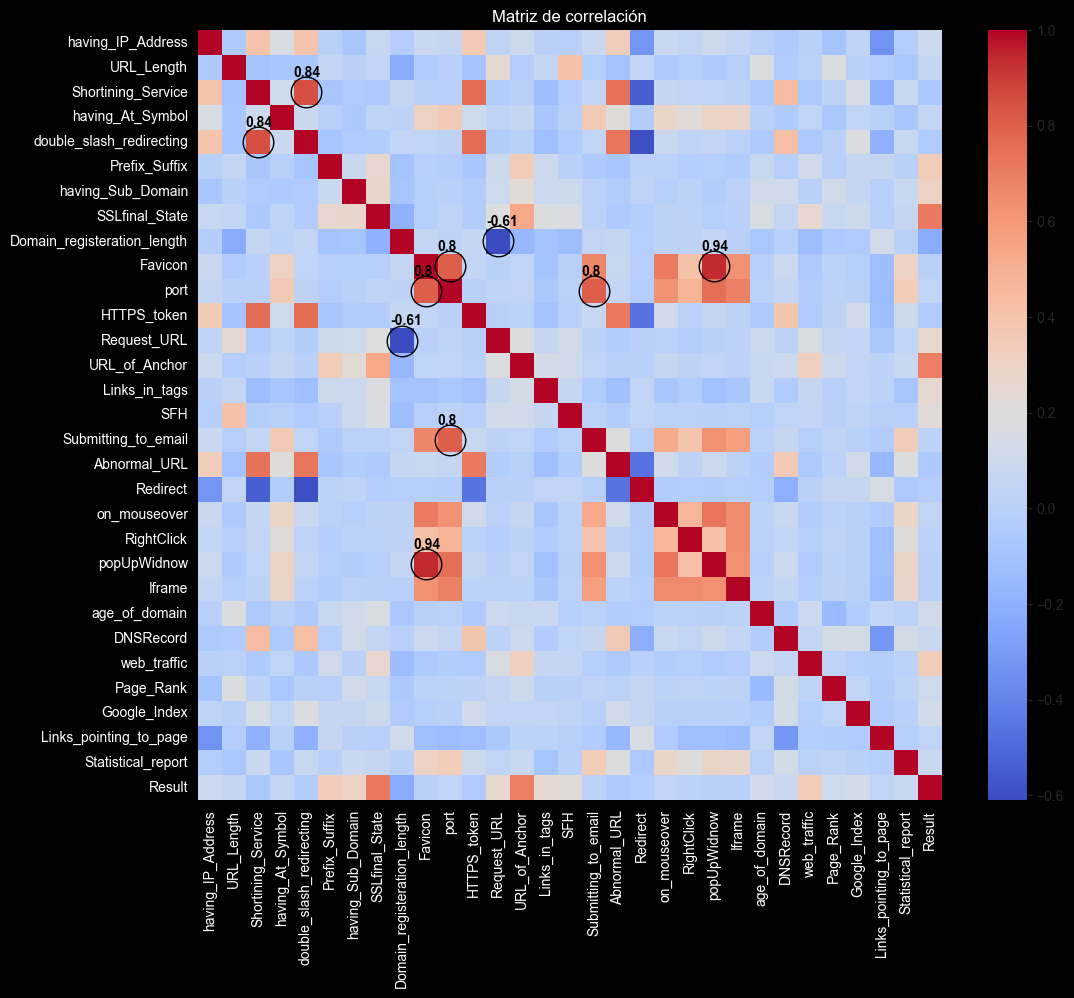

In [6]:
plt.figure(figsize=(12, 10), facecolor='black')
ax = plt.gca()
ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')
plt.title('Matriz de correlación', color='white')
corr_matrix = df.corr()

sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, cbar=True, annot_kws={"fontsize": 12, "fontweight": "bold", "color": "white"},)  

for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        if i != j:  
            text = corr_matrix.iloc[i, j]
            if text > 0.78 or text < -0.6:
                plt.text(j, i, round(text, 2),
                         horizontalalignment='left',
                         verticalalignment='bottom',
                         color='black', fontsize=10, fontweight='bold')
                plt.plot(j+0.5, i+0.5, 'o', markersize=22, markerfacecolor='none', markeredgecolor='black', linewidth=10)
                
plt.show()

In [7]:
#from sklearn.preprocessing import StandardScaler

In [8]:
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

In [9]:
#scaler = StandardScaler()
#X = scaler.fit_transform(X)

In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

## Construccion de ANN

In [11]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, BatchNormalization
from keras.wrappers.scikit_learn import KerasClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV #sklearn.grid_search
from keras.callbacks import EarlyStopping

In [12]:
def build_classifier(dropout=True, optimizer='rmsprop', activation='relu'):
    classifier = Sequential()
    
    classifier.add(Dense(units=32, kernel_initializer='uniform', activation=activation, input_dim=X_train.shape[1]))
    #classifier.add(BatchNormalization())
    classifier.add(Dropout(rate=0.5))
        
    classifier.add(Dense(units=16, kernel_initializer='uniform', activation=activation))
    #classifier.add(BatchNormalization())
    classifier.add(Dropout(rate=0.5))
        
    classifier.add(Dense(units=1, kernel_initializer='uniform', activation='sigmoid'))
    
    classifier.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    
    return classifier

In [13]:
#classifier = build_classifier()

In [14]:
#early_stopping = EarlyStopping(monitor='val_accuracy', patience = 10, restore_best_weights=True)

In [15]:
#history = classifier.fit(X_train, y_train, validation_data=(X_test, y_test), batch_size=32, epochs=200, callbacks=[early_stopping])

In [16]:
classifier = KerasClassifier(build_fn=build_classifier, batch_size=32, epochs=100)

C:\Users\Usuario\AppData\Local\Temp\ipykernel_11616\3796242697.py:1: DeprecationWarning: KerasClassifier is deprecated, use Sci-Keras (https://github.com/adriangb/scikeras) instead. See https://www.adriangb.com/scikeras/stable/migration.html for help migrating.
  classifier = KerasClassifier(build_fn=build_classifier, batch_size=32, epochs=100)


In [17]:
history = classifier.fit(X_train, y_train, verbose=1, validation_split=0.2)

Epoch 1/100
222/222 [==============================] - 1s 2ms/step - loss: 0.4940 - accuracy: 0.7956 - val_loss: 0.2653 - val_accuracy: 0.9084
Epoch 2/100
222/222 [==============================] - 0s 2ms/step - loss: 0.2635 - accuracy: 0.9122 - val_loss: 0.2083 - val_accuracy: 0.9214
Epoch 3/100
222/222 [==============================] - 0s 1ms/step - loss: 0.2299 - accuracy: 0.9251 - val_loss: 0.1987 - val_accuracy: 0.9175
Epoch 4/100
222/222 [==============================] - 0s 2ms/step - loss: 0.2173 - accuracy: 0.9269 - val_loss: 0.1885 - val_accuracy: 0.9226
Epoch 5/100
222/222 [==============================] - 0s 2ms/step - loss: 0.2068 - accuracy: 0.9316 - val_loss: 0.1858 - val_accuracy: 0.9226
Epoch 6/100
222/222 [==============================] - 0s 2ms/step - loss: 0.1988 - accuracy: 0.9310 - val_loss: 0.1777 - val_accuracy: 0.9271
Epoch 7/100
222/222 [==============================] - 0s 2ms/step - loss: 0.1900 - accuracy: 0.9336 - val_loss: 0.1754 - val_accuracy: 0.9271

In [18]:
from sklearn.metrics import recall_score, f1_score

In [19]:
# Predecir las etiquetas
y_pred = classifier.predict(X_test)

test_accuracy = classifier.score(X_test, y_test)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Recall: {recall}")
print(f"F1-Score: {f1}")
print(f"Test Accuracy: {test_accuracy}")


70/70 [==============================] - 0s 996us/step - loss: 0.1408 - accuracy: 0.9475
Recall: 0.9532163742690059
F1-Score: 0.9516263552960801
Test Accuracy: 0.9475350379943848


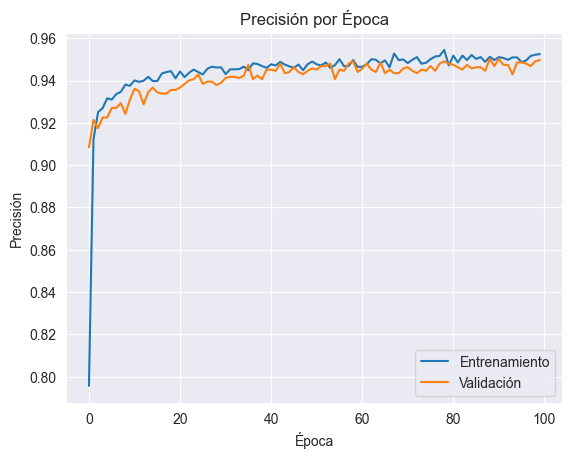

In [20]:
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Precisión por Época')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()
plt.show()


In [21]:
#parameters = {
#    'batch_size' : [32],
#    'epochs' : [100], 
#    'optimizer' : ['rmsprop'], 
#    # completa el diccionario con las funciones de activacion
#    'activation' : ['relu']    
#}

#parameters = {
#    'batch_size': [16, 32, 64],
#    'epochs': [50, 100, 150],
#    'optimizer': ['adam', 'rmsprop'],
#    'activation': ['relu', 'tanh']
#}

In [22]:
#grid_search = GridSearchCV(estimator=classifier, 
#                           param_grid=parameters, 
#                           scoring='accuracy', 
#                           cv=10, 
#                           verbose=1, 
#                           n_jobs=-1)
#grid_search = grid_search.fit(X_train, y_train)

In [23]:
#classifier.predict(X_test)

In [24]:
#best_parameters = grid_search.best_params_
#best_accuracy = grid_search.best_score_

In [33]:
plt.figure(figsize=(12, 5), facecolor='black')

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

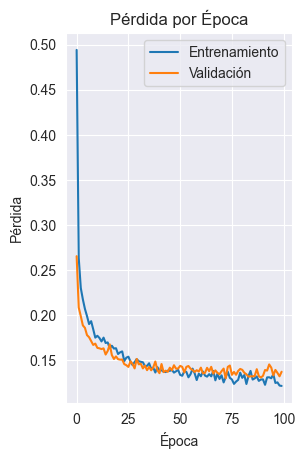

In [34]:
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida por Época')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()

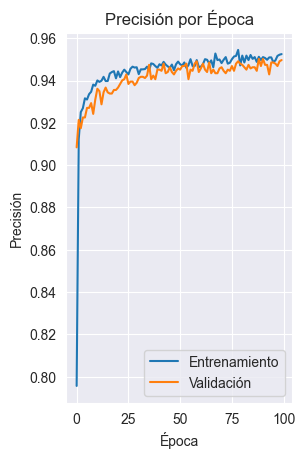

In [35]:
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Precisión por Época')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()
plt.show()

In [28]:
from sklearn.metrics import confusion_matrix, classification_report

In [29]:
y_pred = (classifier.predict(X_test) > 0.5).astype('int')

70/70 [==============================] - 0s 972us/step


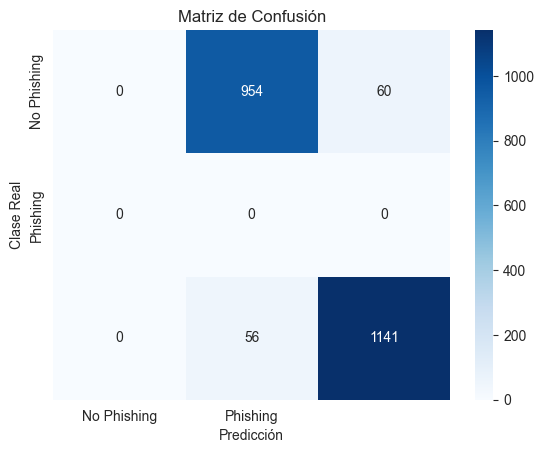

In [30]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Phishing', 'Phishing'], yticklabels=['No Phishing', 'Phishing'])
plt.title('Matriz de Confusión')
plt.ylabel('Clase Real')
plt.xlabel('Predicción')
plt.show()

In [31]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          -1       0.00      0.00      0.00      1014
           0       0.00      0.00      0.00         0
           1       0.95      0.95      0.95      1197

    accuracy                           0.52      2211
   macro avg       0.32      0.32      0.32      2211
weighted avg       0.51      0.52      0.52      2211



e:\Usuarios\Desktop\deeplearning-az\deeplearningvenv\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
e:\Usuarios\Desktop\deeplearning-az\deeplearningvenv\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
e:\Usuarios\Desktop\deeplearning-az\deeplearningvenv\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg